# General Purpose EDA + Data Transformer

Drop any CSV dataset in the config cell and this notebook will:
1. **Profile** the data — shape, types, missing values, distributions, correlations
2. **Analyse** the target variable and feature relationships
3. **Transform** train and test data identically via a fitted `DataTransformer`

Only the **CONFIG** cell needs to be changed between datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm.auto import tqdm
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.max_open_warning': 0, 'figure.dpi': 100})

print('Libraries loaded.')

Libraries loaded.


## CONFIG — Edit this cell for your dataset

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_PATH  = '../data/train.csv'
TEST_PATH   = '../data/test.csv'   # set to None if no test file
SUB_PATH    = '../data/sample_submission.csv'  # set to None if not needed

# ── Column roles ──────────────────────────────────────────────────────────────
TARGET_COL  = 'Churn'   # set to None for unsupervised / unlabelled data
ID_COLS     = ['id']    # columns to drop before analysis & transformations

# ── Target mapping (set to None if target is already numeric) ─────────────────
TARGET_MAP  = {'Yes': 1, 'No': 0}   # e.g. {'Yes':1,'No':0} or None

# ── Transformer options ───────────────────────────────────────────────────────
ENCODE_CATEGORICALS = True   # Label-encode object columns
IMPUTE_NUMERICS     = True   # Fill numeric NaNs with median
IMPUTE_CATS         = True   # Fill categorical NaNs with 'Missing'
SCALE_NUMERICS      = False  # StandardScaler on numeric columns (off by default for tree models)

# ── Plot limits ───────────────────────────────────────────────────────────────
MAX_CAT_UNIQUE      = 20     # max unique values to plot for a categorical column
SAMPLE_SCATTER_FRAC = 0.2    # fraction of rows to use in scatter plots

print('Config loaded.')
print(f'  Train : {TRAIN_PATH}')
print(f'  Test  : {TEST_PATH}')
print(f'  Target: {TARGET_COL}')

Config loaded.
  Train : ../data/train.csv
  Test  : ../data/test.csv
  Target: Churn


## 1. Load Data

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)  if TEST_PATH  else None
sub_df   = pd.read_csv(SUB_PATH)   if SUB_PATH   else None

# Apply target mapping
if TARGET_COL and TARGET_MAP and TARGET_COL in train_df.columns:
    if train_df[TARGET_COL].dtype == 'object':
        train_df[TARGET_COL] = train_df[TARGET_COL].map(TARGET_MAP)
        print(f"Target '{TARGET_COL}' mapped: {TARGET_MAP}")

print(f'\nTrain : {train_df.shape[0]:,} rows × {train_df.shape[1]} cols')
if test_df is not None:
    print(f'Test  : {test_df.shape[0]:,} rows × {test_df.shape[1]} cols')
train_df.head()

Target 'Churn' mapped: {'Yes': 1, 'No': 0}

Train : 594,194 rows × 21 cols
Test  : 254,655 rows × 20 cols


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


## 2. Data Profile

In [4]:
# ── Column types ──────────────────────────────────────────────────────────────
num_cols = train_df.select_dtypes(include='number').columns.tolist()
cat_cols = train_df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in num_cols if c not in ID_COLS + ([TARGET_COL] if TARGET_COL else [])]
cat_cols = [c for c in cat_cols if c not in ID_COLS]

print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical cols ({len(cat_cols)}): {cat_cols}')
print()
train_df.describe(include='all').T

Numeric columns  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical cols (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,594194.0,NaN,NaN,NaN,297096.5,171529.177263,0.0,148548.25,297096.5,445644.75,594193.0
gender,594194,2,Female,298738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,594194.0,NaN,NaN,NaN,0.114102,0.317936,0.0,0.0,0.0,0.0,1.0
Partner,594194,2,Yes,309554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,594194,2,No,414362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,594194.0,NaN,NaN,NaN,36.577258,25.061922,1.0,12.0,35.0,62.0,72.0
PhoneService,594194,2,Yes,557893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,594194,3,No,283384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,594194,3,Fiber optic,272386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,594194,3,No,289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ── Missing value heatmap ─────────────────────────────────────────────────────
miss = train_df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

if miss.empty:
    print('No missing values in train data.')
else:
    print(f'{len(miss)} columns have missing values:')
    fig, ax = plt.subplots(figsize=(10, max(3, len(miss) * 0.4)))
    bars = ax.barh(miss.index, miss.values * 100, color='steelblue')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column (Train)')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()

if test_df is not None:
    test_miss = test_df.isnull().mean()
    test_miss = test_miss[test_miss > 0]
    if not test_miss.empty:
        print(f'\nTest also has missing values in: {test_miss.index.tolist()}')

No missing values in train data.


## 3. Target Variable

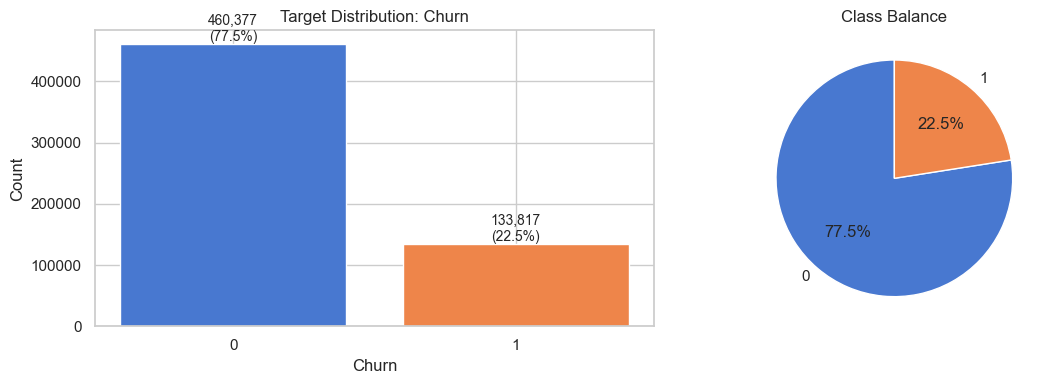

Imbalance ratio (majority/minority): 3.44x
  ⚠ Significant imbalance — use stratified CV and AUC/F1 as metrics.


In [6]:
if TARGET_COL and TARGET_COL in train_df.columns:
    target = train_df[TARGET_COL]
    n_unique = target.nunique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot
    vc = target.value_counts()
    axes[0].bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted'))
    for i, (val, cnt) in enumerate(zip(vc.index, vc.values)):
        axes[0].text(i, cnt + 0.01 * len(target), f'{cnt:,}\n({100*cnt/len(target):.1f}%)',
                     ha='center', fontsize=10)
    axes[0].set_title(f'Target Distribution: {TARGET_COL}')
    axes[0].set_xlabel(TARGET_COL)
    axes[0].set_ylabel('Count')

    # Pie chart
    axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%',
                colors=sns.color_palette('muted'), startangle=90)
    axes[1].set_title('Class Balance')

    plt.tight_layout()
    plt.show()

    imbalance_ratio = vc.max() / vc.min()
    print(f'Imbalance ratio (majority/minority): {imbalance_ratio:.2f}x')
    if imbalance_ratio > 3:
        print('  ⚠ Significant imbalance — use stratified CV and AUC/F1 as metrics.')
else:
    print('No TARGET_COL set — skipping target analysis.')

## 4. Numerical Features

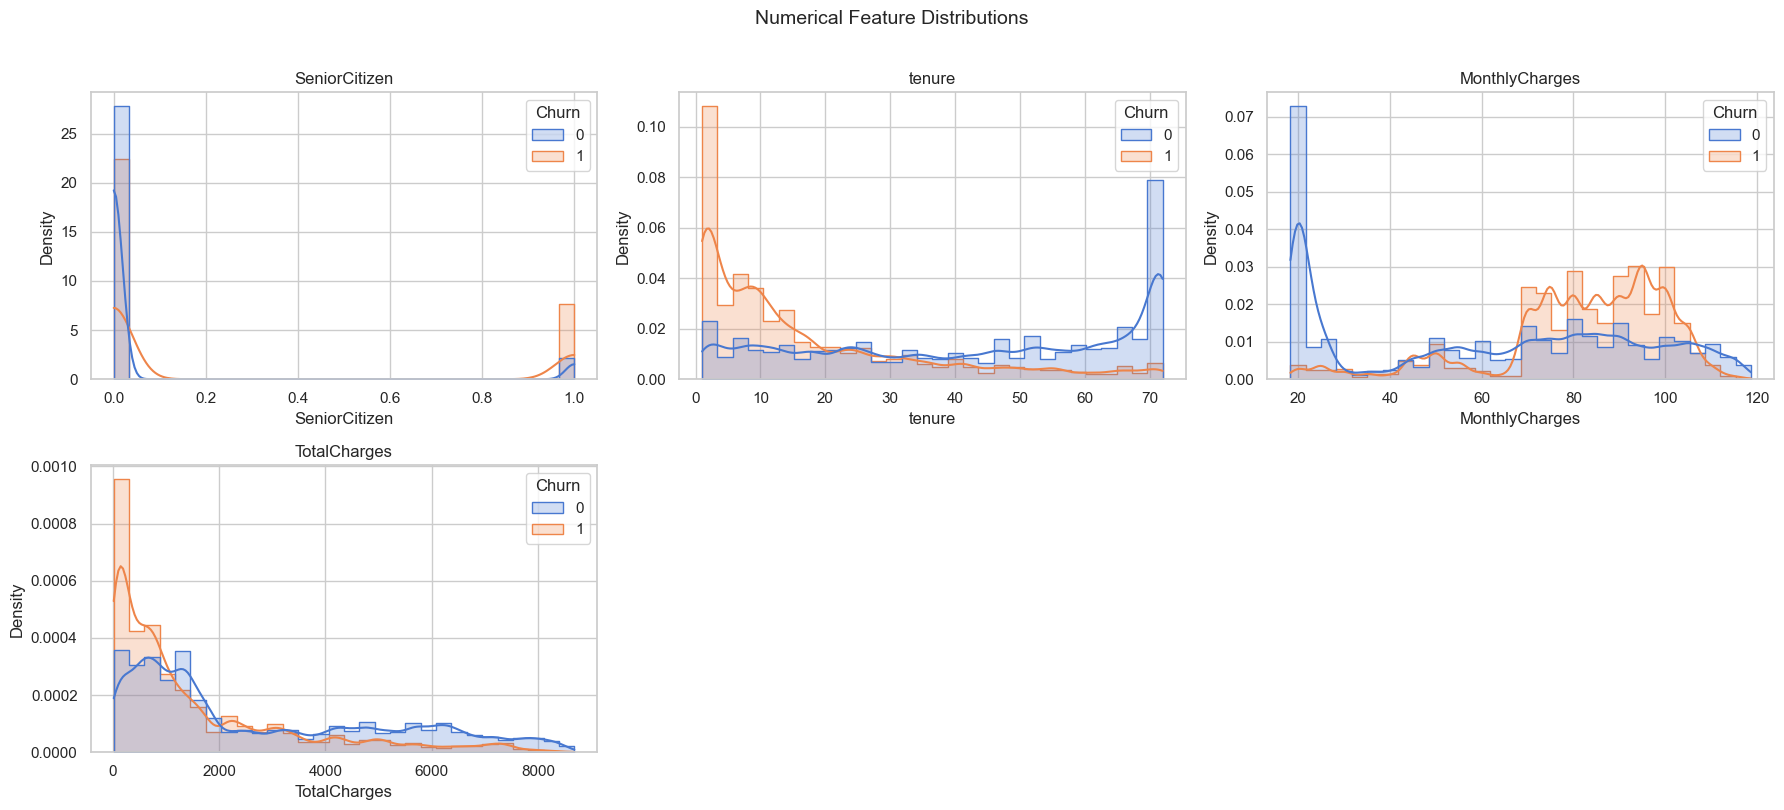

In [7]:
# ── Distributions ─────────────────────────────────────────────────────────────
if num_cols:
    n_cols = min(3, len(num_cols))
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        if TARGET_COL and TARGET_COL in train_df.columns:
            sns.histplot(data=train_df, x=col, hue=TARGET_COL, kde=True,
                         bins=30, ax=axes[i], element='step',
                         stat='density', common_norm=False)
        else:
            sns.histplot(data=train_df, x=col, kde=True, bins=30, ax=axes[i])
        axes[i].set_title(f'{col}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Numerical Feature Distributions', y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

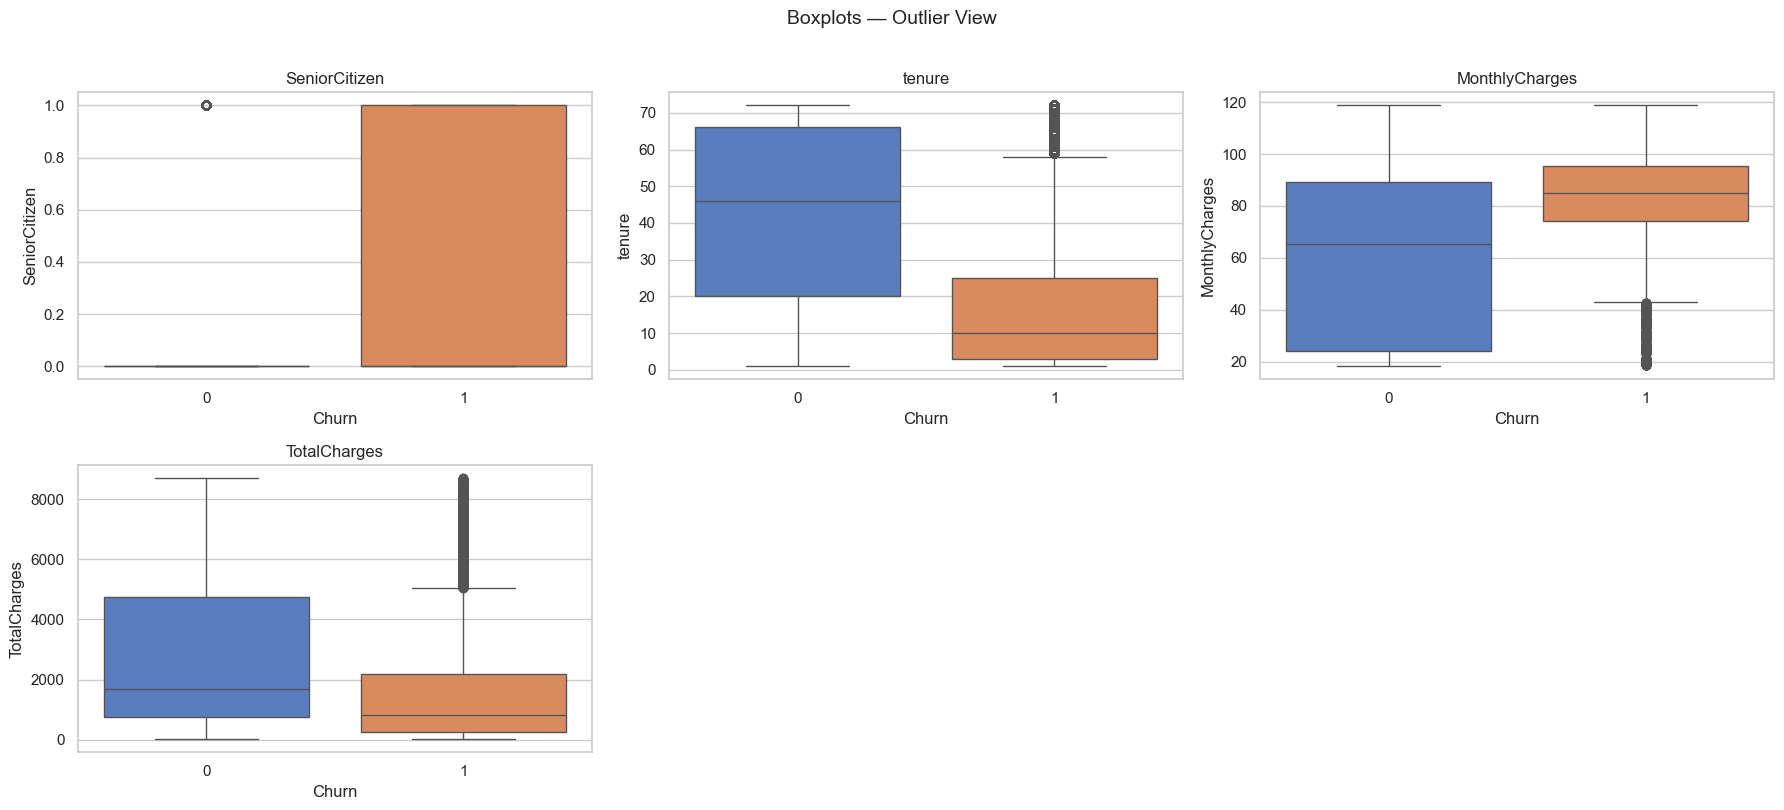

In [8]:
# ── Boxplots (outlier detection) ──────────────────────────────────────────────
if num_cols:
    n_cols = min(3, len(num_cols))
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        if TARGET_COL and TARGET_COL in train_df.columns:
            sns.boxplot(data=train_df, x=TARGET_COL, y=col, ax=axes[i], palette='muted')
        else:
            sns.boxplot(data=train_df, y=col, ax=axes[i])
        axes[i].set_title(f'{col}')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Boxplots — Outlier View', y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

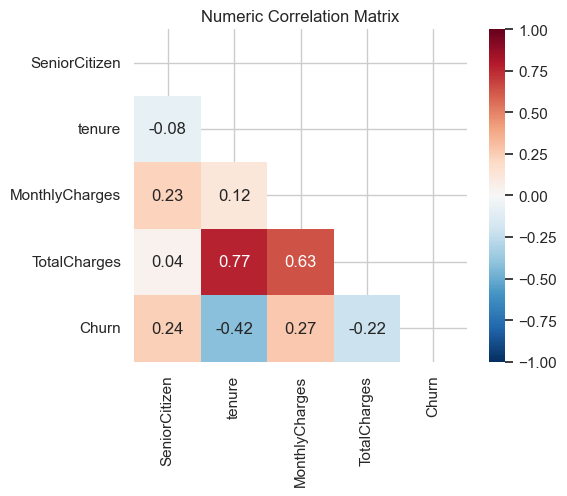

In [9]:
# ── Correlation heatmap (numeric only) ───────────────────────────────────────
if len(num_cols) > 1:
    cols_for_corr = num_cols + ([TARGET_COL] if TARGET_COL in train_df.columns else [])
    corr = train_df[cols_for_corr].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(6, len(cols_for_corr)), max(5, len(cols_for_corr) - 1)))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title('Numeric Correlation Matrix')
    plt.tight_layout()
    plt.show()

## 5. Categorical Features

In [10]:
# ── Cardinality summary ───────────────────────────────────────────────────────
if cat_cols:
    card = pd.DataFrame({
        'n_unique':      [train_df[c].nunique() for c in cat_cols],
        'missing_pct':   [train_df[c].isnull().mean() * 100 for c in cat_cols],
        'top_value':     [train_df[c].mode()[0] if not train_df[c].mode().empty else None for c in cat_cols],
        'top_freq_pct':  [train_df[c].value_counts(normalize=True).iloc[0] * 100 if train_df[c].notna().any() else 0 for c in cat_cols],
    }, index=cat_cols)
    display(card.sort_values('n_unique', ascending=False))
else:
    print('No categorical columns found.')

,n_unique,missing_pct,top_value,top_freq_pct
PaymentMethod,4,0.0,Electronic check,36.246075
MultipleLines,3,0.0,No,47.692168
InternetService,3,0.0,Fiber optic,45.841257
OnlineSecurity,3,0.0,No,48.717086
OnlineBackup,3,0.0,No,42.087769
DeviceProtection,3,0.0,No,41.632362
TechSupport,3,0.0,No,48.565115
StreamingTV,3,0.0,Yes,40.441506
StreamingMovies,3,0.0,Yes,40.632352
Contract,3,0.0,Month-to-month,50.306466


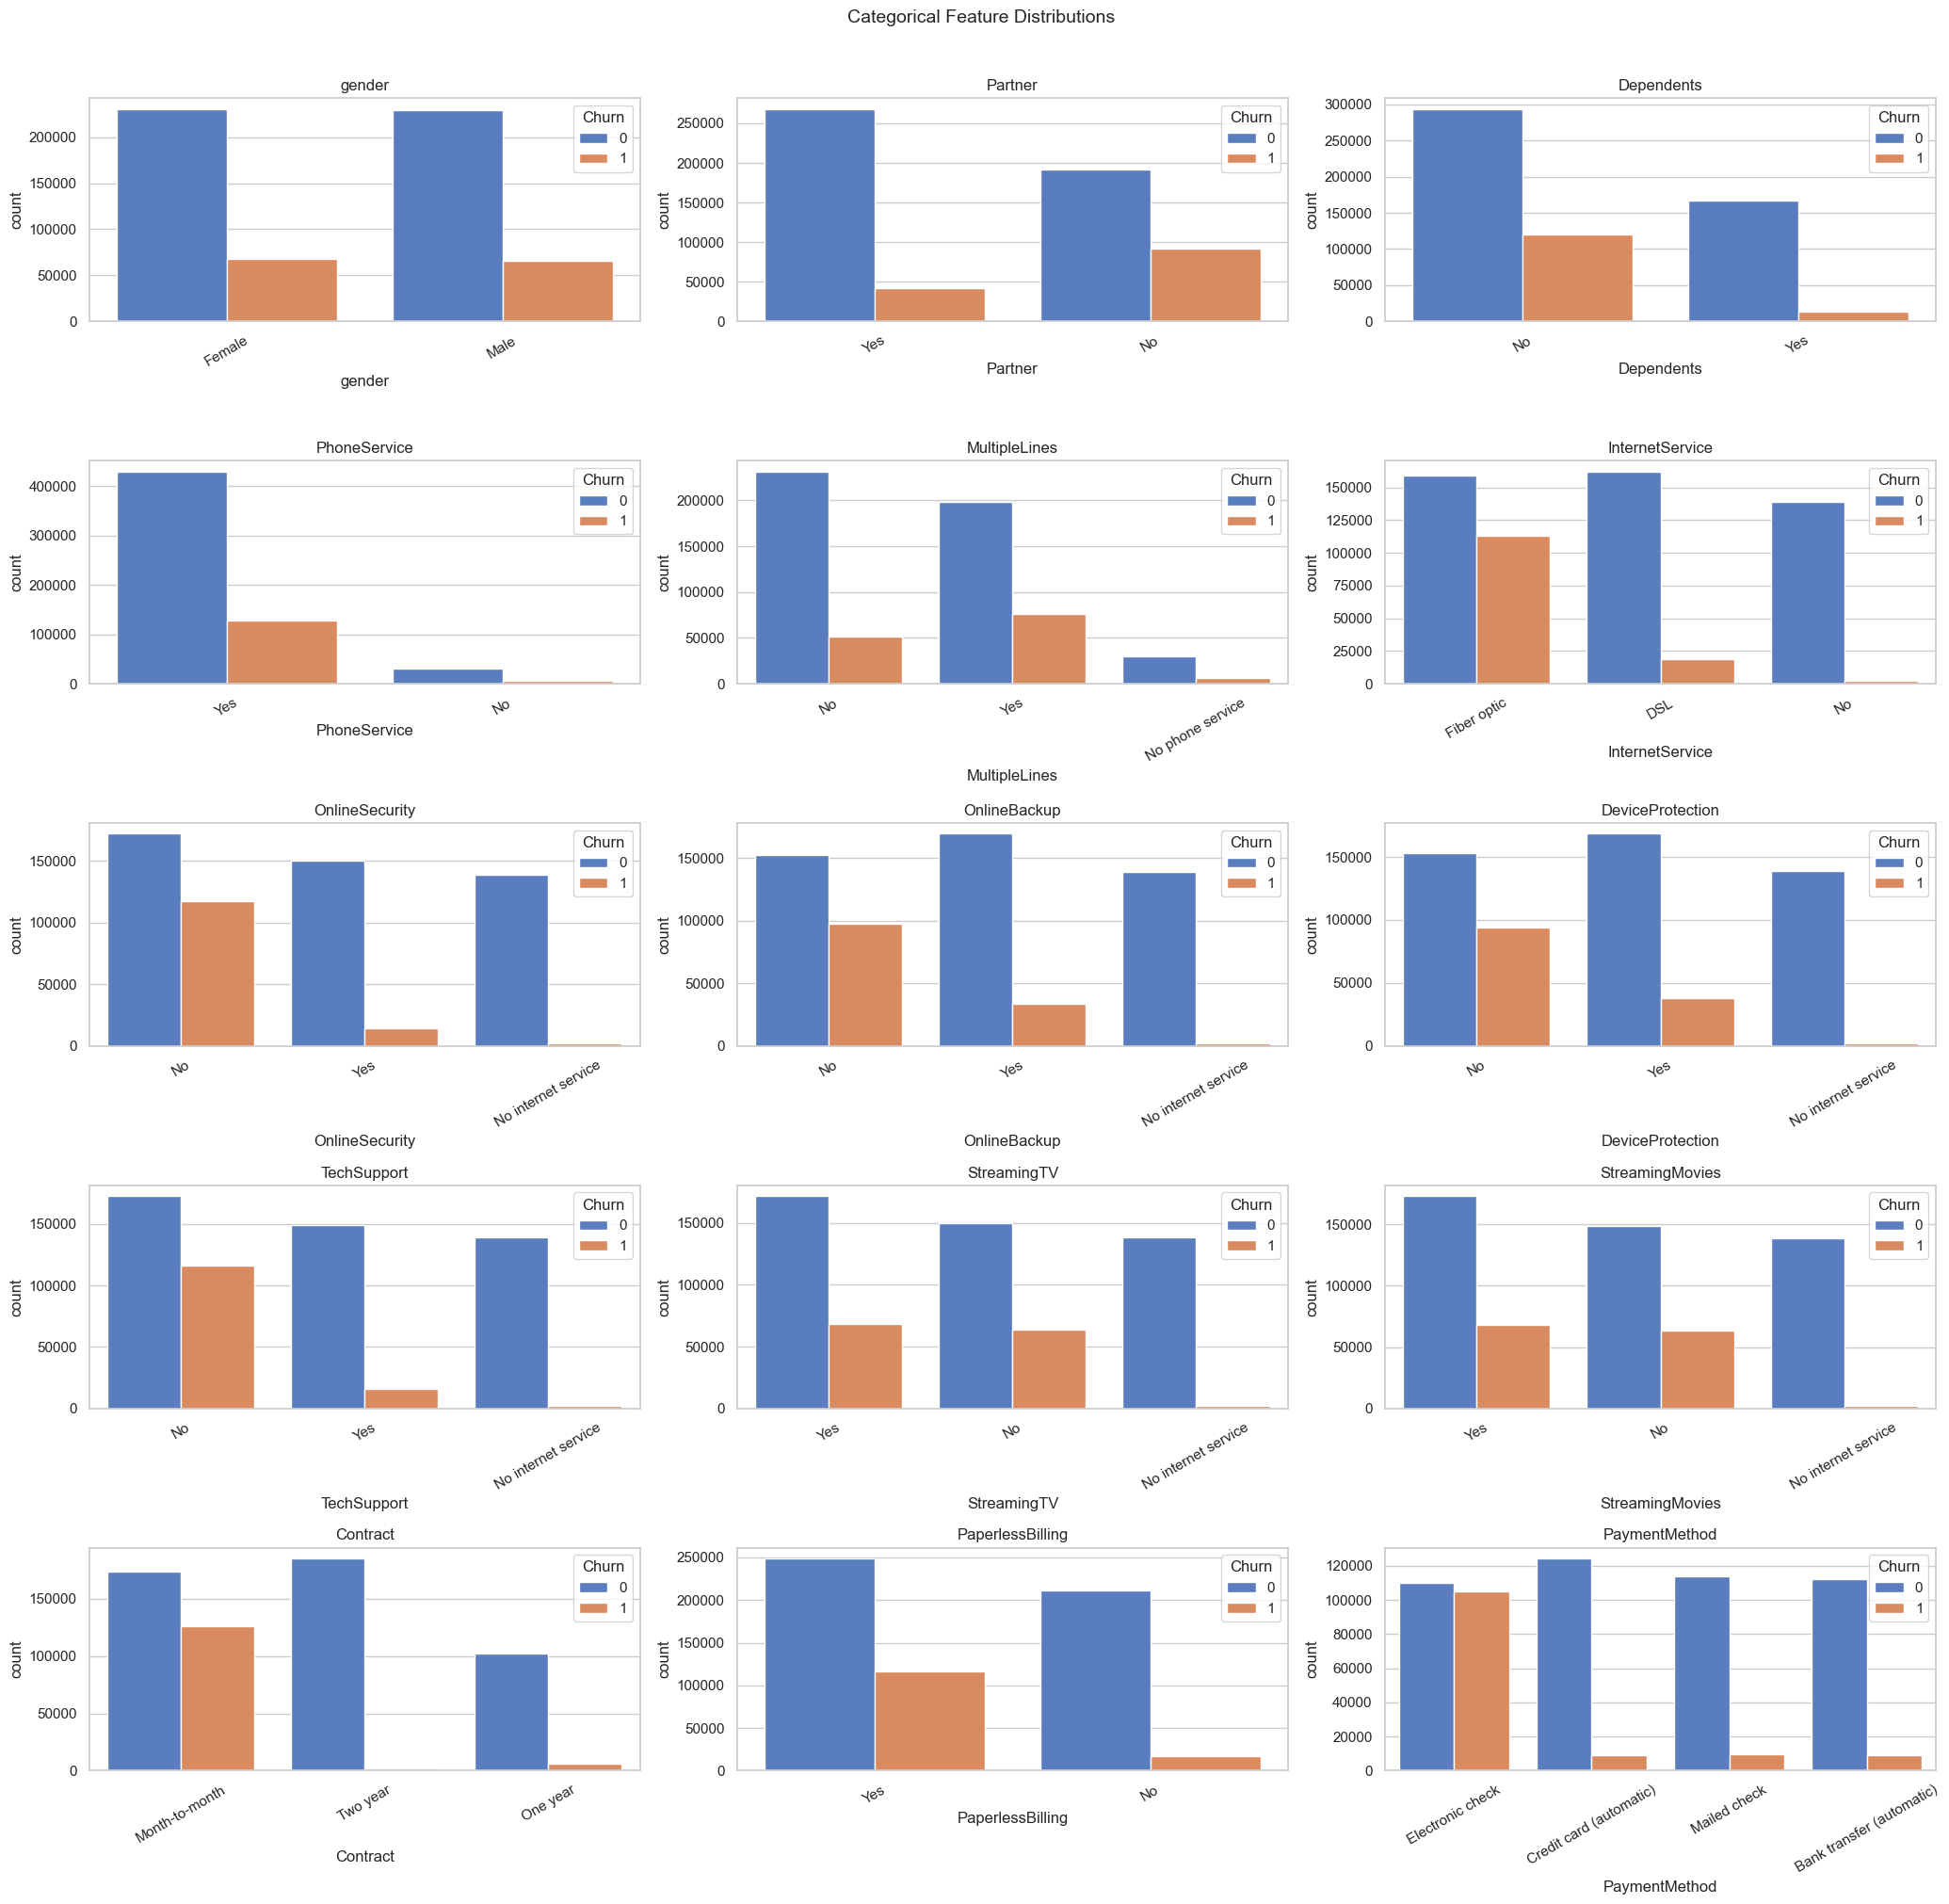

In [11]:
# ── Count plots (with target hue if available) ────────────────────────────────
plottable_cats = [c for c in cat_cols if train_df[c].nunique() <= MAX_CAT_UNIQUE]

if plottable_cats:
    n_cols = min(3, len(plottable_cats))
    n_rows = int(np.ceil(len(plottable_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(plottable_cats):
        if TARGET_COL and TARGET_COL in train_df.columns:
            sns.countplot(data=train_df, x=col, hue=TARGET_COL, ax=axes[i],
                          order=train_df[col].value_counts().index)
        else:
            sns.countplot(data=train_df, x=col, ax=axes[i],
                          order=train_df[col].value_counts().index)
        axes[i].set_title(f'{col}')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Categorical Feature Distributions', y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

skipped = [c for c in cat_cols if c not in plottable_cats]
if skipped:
    print(f'Skipped (>{MAX_CAT_UNIQUE} unique values): {skipped}')

## 6. Full Feature Correlation with Target

Encoding for correlation:   0%|          | 0/15 [00:00<?, ?it/s]

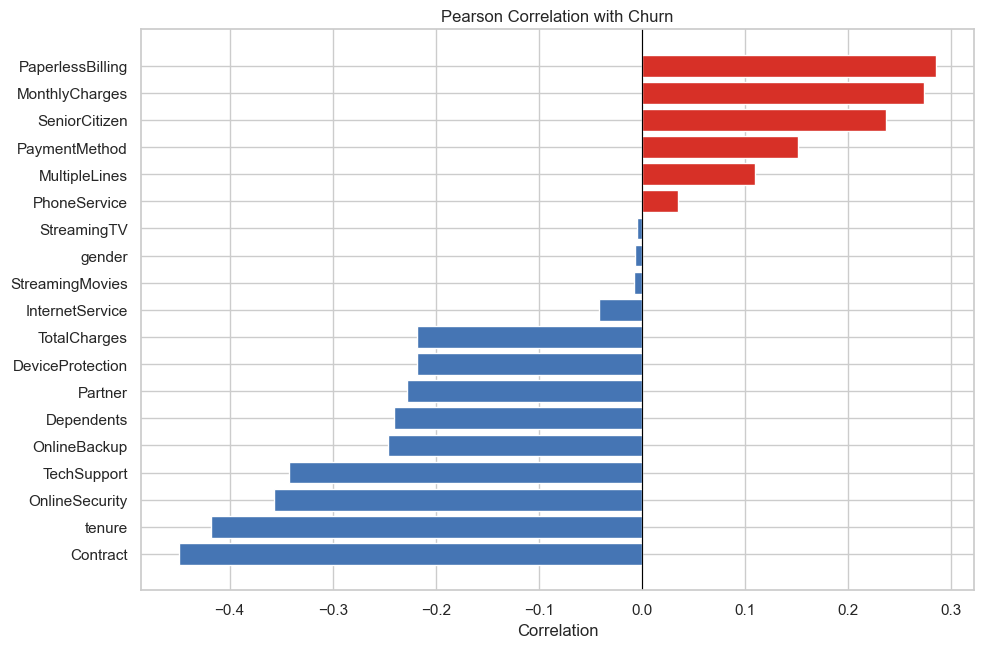


Top 5 positive correlates:
MultipleLines       0.109689
PaymentMethod       0.151097
SeniorCitizen       0.236362
MonthlyCharges      0.272997
PaperlessBilling    0.285107

Top 5 negative correlates:
Contract         -0.449285
tenure           -0.418453
OnlineSecurity   -0.356786
TechSupport      -0.342550
OnlineBackup     -0.246620


In [12]:
if TARGET_COL and TARGET_COL in train_df.columns:
    corr_df = train_df.copy()

    for col in tqdm(cat_cols, desc='Encoding for correlation'):
        corr_df[col] = LabelEncoder().fit_transform(corr_df[col].fillna('Missing').astype(str))

    feature_cols = [c for c in corr_df.columns if c not in ID_COLS and c != TARGET_COL]
    target_corr  = corr_df[feature_cols].corrwith(corr_df[TARGET_COL]).sort_values()

    colors = ['#d73027' if v > 0 else '#4575b4' for v in target_corr.values]
    fig, ax = plt.subplots(figsize=(10, max(4, len(target_corr) * 0.35)))
    ax.barh(target_corr.index, target_corr.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Pearson Correlation with {TARGET_COL}')
    ax.set_xlabel('Correlation')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 positive correlates:')
    print(target_corr.tail(5).to_string())
    print('\nTop 5 negative correlates:')
    print(target_corr.head(5).to_string())
else:
    print('No TARGET_COL set — skipping correlation analysis.')

## 7. Bivariate Scatter (Numeric Pairs)

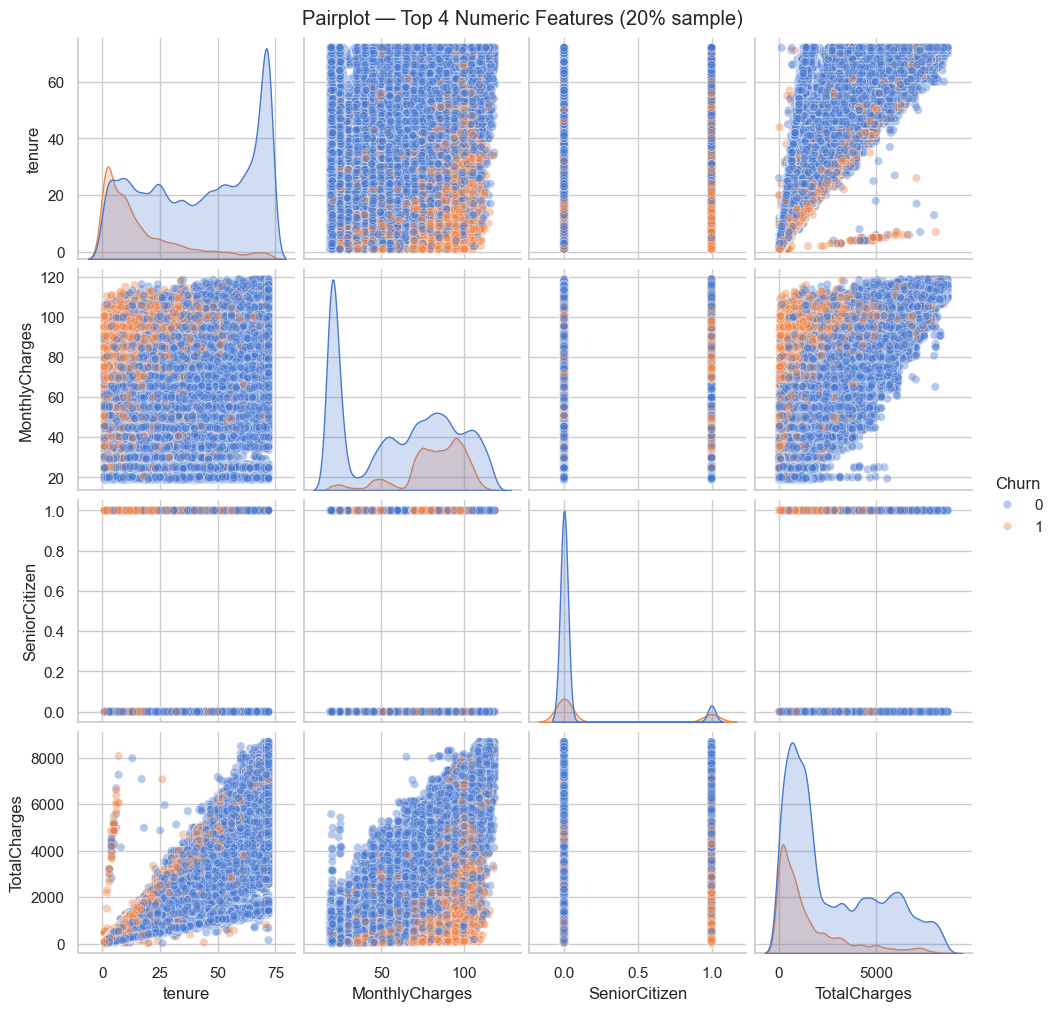

In [13]:
if len(num_cols) >= 2:
    sample = train_df.sample(frac=SAMPLE_SCATTER_FRAC, random_state=42)
    hue_col = TARGET_COL if (TARGET_COL and TARGET_COL in train_df.columns) else None

    # Pick top 5 numeric cols by correlation with target (or just first 5)
    if hue_col:
        top_num = target_corr.reindex(num_cols).dropna().abs().sort_values(ascending=False).head(5).index.tolist()
    else:
        top_num = num_cols[:5]

    if len(top_num) >= 2:
        g = sns.pairplot(sample[top_num + ([hue_col] if hue_col else [])],
                         hue=hue_col, plot_kws={'alpha': 0.4}, diag_kind='kde')
        g.fig.suptitle(f'Pairplot — Top {len(top_num)} Numeric Features ({int(SAMPLE_SCATTER_FRAC*100)}% sample)', y=1.01)
        plt.show()
else:
    print('Need at least 2 numeric columns for pairplot.')

## 8. DataTransformer — Fit on Train, Apply to Test

The `DataTransformer` class learns everything from train data only (encoders, medians, scalers) and replicates the **exact same** transforms on test data. No information from test leaks into fitting.

In [14]:
class DataTransformer:
    """
    Fits all transformations on train data and applies identical transforms to
    any other DataFrame (e.g. test). Safe against data leakage.

    Transformations (each toggleable):
      - Categorical NaN fill  → 'Missing'
      - Numeric NaN fill      → median from train
      - Label encoding        → fitted on train, applied to test
      - Standard scaling      → fitted on train, applied to test
    """

    def __init__(self,
                 encode_categoricals=True,
                 impute_numerics=True,
                 impute_cats=True,
                 scale_numerics=False,
                 drop_cols=None):
        self.encode_categoricals = encode_categoricals
        self.impute_numerics     = impute_numerics
        self.impute_cats         = impute_cats
        self.scale_numerics      = scale_numerics
        self.drop_cols           = drop_cols or []

        self._label_encoders  = {}
        self._numeric_medians = {}
        self._scaler          = None
        self._numeric_cols    = []
        self._cat_cols        = []
        self._fitted          = False
        self.transform_log    = []

    def fit(self, df, target_col=None):
        """Learn all parameters from df (should be train data only)."""
        df = df.copy()
        exclude = set(self.drop_cols + ([target_col] if target_col else []))

        self._cat_cols     = [c for c in df.select_dtypes('object').columns  if c not in exclude]
        self._numeric_cols = [c for c in df.select_dtypes('number').columns  if c not in exclude]

        if self.impute_cats:
            for col in self._cat_cols:
                df[col] = df[col].fillna('Missing')

        if self.impute_numerics:
            for col in tqdm(self._numeric_cols, desc='Fitting medians', leave=False):
                self._numeric_medians[col] = df[col].median()

        if self.encode_categoricals:
            for col in tqdm(self._cat_cols, desc='Fitting encoders', leave=False):
                le = LabelEncoder()
                le.fit(df[col].astype(str))
                self._label_encoders[col] = le

        if self.scale_numerics and self._numeric_cols:
            temp = df[self._numeric_cols].copy()
            for col in self._numeric_cols:
                temp[col] = temp[col].fillna(self._numeric_medians.get(col, 0))
            self._scaler = StandardScaler().fit(temp)

        self._fitted = True
        print('DataTransformer fitted on train data.')
        print(f'  Categorical cols : {len(self._cat_cols)}')
        print(f'  Numeric cols     : {len(self._numeric_cols)}')
        return self

    def transform(self, df, label='data'):
        """Apply fitted transformations to df. Works on both train and test."""
        assert self._fitted, 'Call .fit(train_df) before .transform()'
        df = df.copy()
        self.transform_log = []

        # Drop configured columns
        drop_present = [c for c in self.drop_cols if c in df.columns]
        if drop_present:
            df = df.drop(columns=drop_present)
            self.transform_log.append(f'Dropped: {drop_present}')

        # Categorical imputation
        if self.impute_cats:
            for col in [c for c in self._cat_cols if c in df.columns]:
                n = df[col].isnull().sum()
                if n > 0:
                    df[col] = df[col].fillna('Missing')
                    self.transform_log.append(f"Imputed {n} NaN → 'Missing' in '{col}'")

        # Numeric imputation
        if self.impute_numerics:
            for col in [c for c in self._numeric_cols if c in df.columns]:
                n = df[col].isnull().sum()
                if n > 0:
                    df[col] = df[col].fillna(self._numeric_medians[col])
                    self.transform_log.append(f"Imputed {n} NaN → median ({self._numeric_medians[col]:.4g}) in '{col}'")

        # Label encoding — unseen categories mapped to -1
        if self.encode_categoricals:
            for col, le in self._label_encoders.items():
                if col not in df.columns:
                    continue
                known = set(le.classes_)
                unseen = set(df[col].dropna().astype(str).unique()) - known
                if unseen:
                    df[col] = df[col].apply(lambda x: x if str(x) in known else '__unseen__')
                    if '__unseen__' not in le.classes_:
                        le.classes_ = np.append(le.classes_, '__unseen__')
                    self.transform_log.append(f"'{col}': {len(unseen)} unseen categories mapped to '__unseen__'")
                df[col] = le.transform(df[col].astype(str))

        # Standard scaling
        if self.scale_numerics and self._scaler:
            num_present = [c for c in self._numeric_cols if c in df.columns]
            df[num_present] = self._scaler.transform(df[num_present])
            self.transform_log.append(f'Scaled {len(num_present)} numeric columns')

        print(f'\nTransformed {label} → {df.shape}')
        for entry in self.transform_log:
            print(f'  • {entry}')
        return df

    def fit_transform(self, df, target_col=None, label='train'):
        return self.fit(df, target_col).transform(df, label=label)

    def summary(self):
        print(f'Fitted  : {self._fitted}')
        print(f'Encoders: {list(self._label_encoders.keys())}')
        print(f'Medians : { {k: round(v, 4) for k, v in self._numeric_medians.items()} }')
        print(f'Scaler  : {self._scaler}')

print('DataTransformer class defined.')

DataTransformer class defined.


## 9. Apply Transformations

In [15]:
transformer = DataTransformer(
    encode_categoricals = ENCODE_CATEGORICALS,
    impute_numerics     = IMPUTE_NUMERICS,
    impute_cats         = IMPUTE_CATS,
    scale_numerics      = SCALE_NUMERICS,
    drop_cols           = ID_COLS,
)

# Fit only on train, then transform separately to avoid leakage
transformer.fit(train_df, target_col=TARGET_COL)

train_transformed = transformer.transform(train_df, label='train')

if test_df is not None:
    test_transformed = transformer.transform(test_df, label='test')

Fitting medians:   0%|          | 0/4 [00:00<?, ?it/s]

Fitting encoders:   0%|          | 0/15 [00:00<?, ?it/s]

DataTransformer fitted on train data.
  Categorical cols : 15
  Numeric cols     : 4

Transformed train → (594194, 20)
  • Dropped: ['id']

Transformed test → (254655, 19)
  • Dropped: ['id']


In [16]:
# ── Sanity check ──────────────────────────────────────────────────────────────
print('Train transformed shape :', train_transformed.shape)
if test_df is not None:
    print('Test  transformed shape :', test_transformed.shape)

print('\nRemaining NaNs (train):', train_transformed.isnull().sum().sum())
if test_df is not None:
    print('Remaining NaNs (test) :', test_transformed.isnull().sum().sum())

train_transformed.head()

Train transformed shape : (594194, 20)
Test  transformed shape : (254655, 19)

Remaining NaNs (train): 0
Remaining NaNs (test) : 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10,1653.85,0
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50,3778.20,0
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40,5841.35,0
3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70,70.70,1
4,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45,70.45,1


## 10. Save Transformed Data (Optional)

In [17]:
SAVE_TRANSFORMED = False   # flip to True to save

if SAVE_TRANSFORMED:
    out_dir = '../data/processed/'
    os.makedirs(out_dir, exist_ok=True)

    train_transformed.to_csv(os.path.join(out_dir, 'train_transformed.csv'), index=False)
    print(f'Saved → {out_dir}train_transformed.csv')

    if test_df is not None:
        test_transformed.to_csv(os.path.join(out_dir, 'test_transformed.csv'), index=False)
        print(f'Saved → {out_dir}test_transformed.csv')
else:
    print('SAVE_TRANSFORMED = False — data not written to disk.')

SAVE_TRANSFORMED = False — data not written to disk.
